In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('../dataset/Churn_Modelling.csv')

In [3]:
df.drop(columns = ['RowNumber', 'CustomerId', 'Surname'], inplace = True)

In [4]:
df = pd.get_dummies(df, columns = ['Geography', 'Gender'], drop_first = True)

In [5]:
x = df.drop('Exited', axis = 1)
y = df['Exited']


In [6]:
from sklearn.model_selection import  train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size= 0.2, random_state=42)

In [7]:
x_train.shape

(8000, 11)

In [8]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [9]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [10]:
model = Sequential()
model.add(Dense(14, activation = 'relu', input_dim = 11))
model.add(Dense(14, activation = 'relu'))
model.add(Dense(1, activation = 'linear'))

/Users/rachin/Desktop/Ai/ai2.0/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
model.compile(loss = 'mean_squared_error', optimizer = 'Adam', metrics =['accuracy'])

## Batch gradient

In [12]:
import time
st = time.time()
history = model.fit(x_train, y_train, epochs =20, validation_split = 0.2, batch_size = 8000 ) #full dataset observe then update weight

print(time.time() - st)

Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.7934 - loss: 0.3577 - val_accuracy: 0.7987 - val_loss: 0.3461
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.7934 - loss: 0.3416 - val_accuracy: 0.7987 - val_loss: 0.3308
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.7934 - loss: 0.3266 - val_accuracy: 0.7987 - val_loss: 0.3165
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.7936 - loss: 0.3125 - val_accuracy: 0.7987 - val_loss: 0.3031
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.7934 - loss: 0.2994 - val_accuracy: 0.7987 - val_loss: 0.2907
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.7934 - loss: 0.2873 - val_accuracy: 0.7987 - val_loss: 0.2792
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.7933 - loss: 0.2762 - val_accuracy: 0.7981 - val_loss: 0.2687
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.7928 - loss: 0.2660 - val_accuracy: 0.7981 - val_loss: 0.2591
Ep

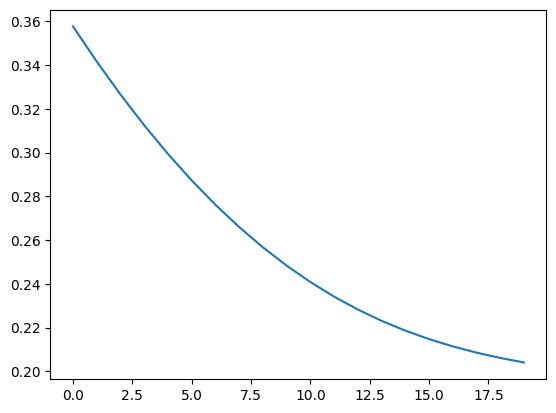

In [13]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])

## Stochastic gradient descent

In [14]:
import time
st = time.time()
history = model.fit(x_train, y_train, epochs =20, validation_split = 0.2, batch_size = 1 ) # weight update after observe one training data sample

print(time.time() - st)

Epoch 1/20
6400/6400 ━━━━━━━━━━━━━━━━━━━━ 4s 593us/step - accuracy: 0.8253 - loss: 0.1340 - val_accuracy: 0.8438 - val_loss: 0.1199
Epoch 2/20
6400/6400 ━━━━━━━━━━━━━━━━━━━━ 4s 555us/step - accuracy: 0.8547 - loss: 0.1140 - val_accuracy: 0.8394 - val_loss: 0.1173
Epoch 3/20
6400/6400 ━━━━━━━━━━━━━━━━━━━━ 4s 631us/step - accuracy: 0.8578 - loss: 0.1096 - val_accuracy: 0.8544 - val_loss: 0.1115
Epoch 4/20
6400/6400 ━━━━━━━━━━━━━━━━━━━━ 4s 546us/step - accuracy: 0.8550 - loss: 0.1081 - val_accuracy: 0.8537 - val_loss: 0.1115
Epoch 5/20
6400/6400 ━━━━━━━━━━━━━━━━━━━━ 4s 587us/step - accuracy: 0.8602 - loss: 0.1066 - val_accuracy: 0.8587 - val_loss: 0.1079
Epoch 6/20
6400/6400 ━━━━━━━━━━━━━━━━━━━━ 4s 580us/step - accuracy: 0.8597 - loss: 0.1067 - val_accuracy: 0.8544 - val_loss: 0.1085
Epoch 7/20
6400/6400 ━━━━━━━━━━━━━━━━━━━━ 4s 603us/step - accuracy: 0.8616 - loss: 0.1058 - val_accuracy: 0.8562 - val_loss: 0.1105
Epoch 8/20
6400/6400 ━━━━━━━━━━━━━━━━━━━━ 4s 597us/step - accuracy: 0.8611 -

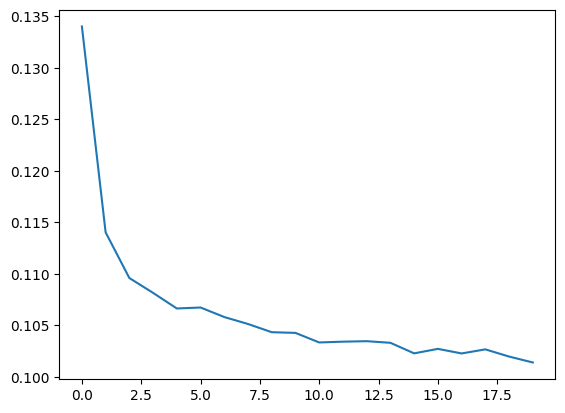

In [15]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])

## Mini batch gradient descent

In [17]:
st = time.time()
history = model.fit(x_train, y_train, epochs = 20, validation_data = (x_test, y_test), batch_size = 32)
end = time.time()
print(end- st)

Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 851us/step - accuracy: 0.8708 - loss: 0.0966 - val_accuracy: 0.8635 - val_loss: 0.1023
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 700us/step - accuracy: 0.8716 - loss: 0.0965 - val_accuracy: 0.8635 - val_loss: 0.1017
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 712us/step - accuracy: 0.8714 - loss: 0.0965 - val_accuracy: 0.8655 - val_loss: 0.1032
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 729us/step - accuracy: 0.8711 - loss: 0.0965 - val_accuracy: 0.8645 - val_loss: 0.1022
Epoch 5/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 971us/step - accuracy: 0.8710 - loss: 0.0963 - val_accuracy: 0.8630 - val_loss: 0.1018
Epoch 6/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 710us/step - accuracy: 0.8719 - loss: 0.0960 - val_accuracy: 0.8645 - val_loss: 0.1022
Epoch 7/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 713us/step - accuracy: 0.8710 - loss: 0.0962 - val_accuracy: 0.8625 - val_loss: 0.1020
Epoch 8/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 716us/step - accuracy: 0.8721 - loss: 0.0960 - 

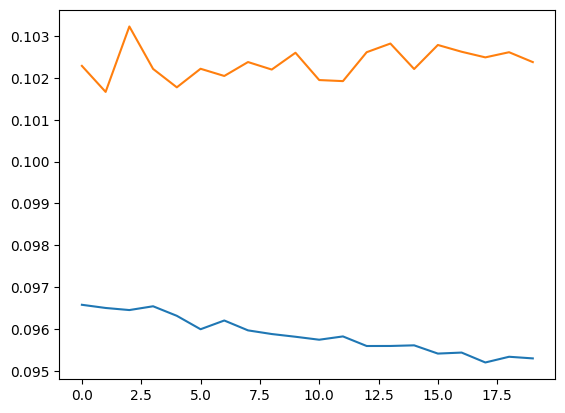

In [18]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

In [19]:
y = model.predict(x_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 857us/step


In [20]:
from sklearn.metrics import r2_score
score = r2_score(y,y_test)
score

-0.5694876909255981